In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Earthquakes.csv")

df.head()
df.shape


(12218, 22)

In [35]:
# ===== COLUMN NAME CLEANING =====

# CHECK
print("Original columns:", df.columns)

# CLEAN
df.columns = df.columns.str.strip().str.lower()

# VERIFY
print("Cleaned columns:", df.columns)

Original columns: Index(['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst',
       'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type',
       'horizontalError', 'depthError', 'magError', 'magNst', 'status',
       'locationSource', 'magSource'],
      dtype='object')
Cleaned columns: Index(['time', 'latitude', 'longitude', 'depth', 'mag', 'magtype', 'nst',
       'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type',
       'horizontalerror', 'deptherror', 'magerror', 'magnst', 'status',
       'locationsource', 'magsource'],
      dtype='object')


In [36]:
# ===== DATE CLEANING =====

# CHECK invalid dates
invalid_dates = df['time'].isnull().sum()
print("Invalid time values:", invalid_dates)

# CLEAN
df['time'] = pd.to_datetime(df['time'], errors='coerce')

# DROP invalid dates
df = df.dropna(subset=['time'])

# FEATURE EXTRACTION
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month
df.shape

Invalid time values: 0


(12118, 24)

In [37]:
# ===== DUPLICATES =====

# CHECK
dup_count = df.duplicated().sum()
print("Duplicates:", dup_count)

# CLEAN
df = df.drop_duplicates()

Duplicates: 89


In [38]:
# ===== MISSING VALUES =====

# CHECK
print(df.isnull().sum())

# CLEAN (only critical columns)
df = df.dropna(subset=['latitude', 'longitude', 'depth', 'mag'])

time                  0
latitude            198
longitude           197
depth               196
mag                 198
magtype               0
nst                4602
gap                   6
dmin               6171
rms                  18
net                   0
id                    0
updated               1
place                 1
type                  1
horizontalerror    6872
deptherror         4100
magerror           6222
magnst              997
status                1
locationsource        1
magsource             1
year                  0
month                 0
dtype: int64


In [39]:
# ===== DEPTH CLEANING =====

# CHECK
print("Negative depth count:", (df['depth'] < 0).sum())

# CLEAN (convert negative to positive)
df['depth'] = df['depth'].apply(lambda x: abs(x) if x < 0 else x)

Negative depth count: 98


In [40]:
# ===== MAGNITUDE CLEANING =====

# CHECK
print("Invalid magnitude:",
      df[(df['mag'] <= 0) | (df['mag'] > 10)].shape[0])

# CLEAN
df = df[(df['mag'] > 0) & (df['mag'] < 10)]

Invalid magnitude: 100


In [41]:
# ===== DEPTH OUTLIERS =====

# CHECK
Q1 = df['depth'].quantile(0.25)
Q3 = df['depth'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['depth'] < Q1 - 1.5*IQR) | (df['depth'] > Q3 + 1.5*IQR)]
print("Outliers:", len(outliers))

# CLEAN
df = df[(df['depth'] >= Q1 - 1.5*IQR) & (df['depth'] <= Q3 + 1.5*IQR)]

Outliers: 972


In [42]:
# ===== FINAL DATASET =====

df = df[[
    'time',
    'latitude',
    'longitude',
    'depth',
    'mag',
    'place',
    'year',
    'month'
]]

print("Final shape:", df.shape)

Final shape: (10759, 8)


In [43]:
# ===== SAVE =====

df.to_csv("cleaned_earthquake_data.csv", index=False)

print("✅ Cleaned dataset saved")

✅ Cleaned dataset saved


In [44]:
# ===== LOAD CLEANED DATA =====

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_earthquake_data.csv")

print(df.shape)
print(df.head())

(10759, 8)
                               time  latitude  longitude   depth  mag  \
0  2024-10-31 01:32:40.503000+00:00   29.8573    92.2470  10.000  4.4   
1  2024-10-30 23:51:31.217000+00:00   28.2099    67.0879  10.000  4.3   
2  2024-10-29 02:35:27.930000+00:00    4.7184    96.2377  42.117  4.6   
3  2024-10-28 13:08:40.107000+00:00   27.8734    94.0243  36.279  4.6   
4  2024-10-23 21:11:18.779000+00:00   32.7498    90.4178  10.000  4.0   

                            place  year  month  
0      113 km ENE of Lhasa, China  2024     10  
1   64 km NE of Khuzdar, Pakistan  2024     10  
2  55 km S of Reuleuet, Indonesia  2024     10  
3        35 km NNE of Ziro, India  2024     10  
4       209 km NW of Nagqu, China  2024     10  


In [45]:
# ===== BASIC STATISTICS =====

print(df.describe())

           latitude     longitude         depth           mag          year  \
count  10759.000000  10759.000000  10759.000000  10759.000000  10759.000000   
mean      19.121075     88.483031     22.652462      4.430027   2013.065434   
std       14.707406     21.765561     15.956076      0.475718      5.745403   
min        1.793000     60.667800      0.800000      2.700000   2005.000000   
25%        5.755100     81.746150     10.000000      4.200000   2008.000000   
50%       21.546100     92.709000     11.000000      4.400000   2012.000000   
75%       30.378450     94.914250     35.000000      4.700000   2018.000000   
max      200.000000    500.000000     72.620000      8.600000   2024.000000   

              month  
count  10759.000000  
mean       6.612232  
std        3.329439  
min        1.000000  
25%        4.000000  
50%        7.000000  
75%       10.000000  
max       12.000000  


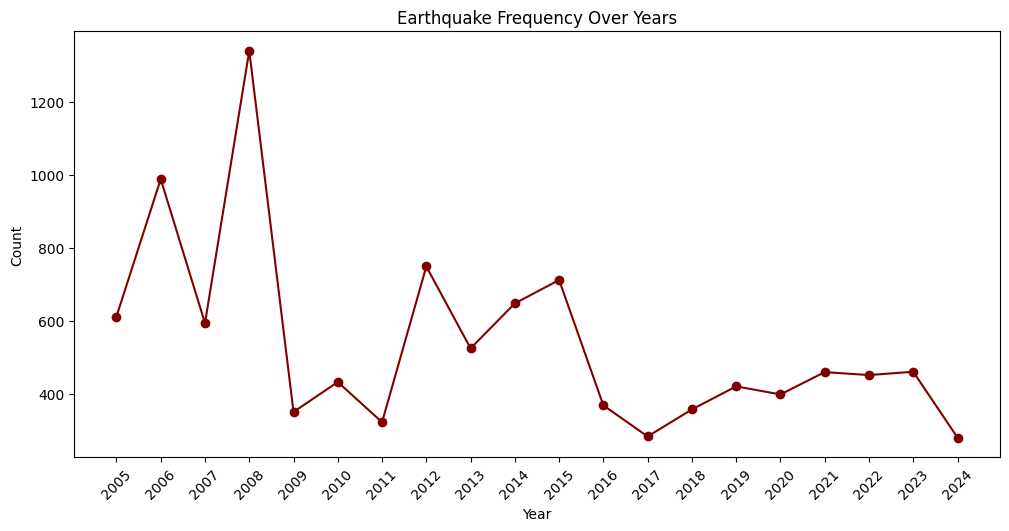

In [49]:
plt.figure(figsize=(10,5))

counts = df['year'].value_counts().sort_index()

plt.plot(counts.index, counts.values, marker='o', color='maroon')

plt.xticks(counts.index, rotation=45)
plt.tight_layout()

plt.title("Earthquake Frequency Over Years")
plt.xlabel("Year")
plt.ylabel("Count")

plt.show()

In [51]:
# ===== MAGNITUDE CATEGORY =====

def categorize_mag(m):
    if m < 3:
        return "Low"
    elif m < 5:
        return "Moderate"
    else:
        return "High"

df['mag_category'] = df['mag'].apply(categorize_mag)

print(df['mag_category'].value_counts())

mag_category
Moderate    9529
High        1225
Low            5
Name: count, dtype: int64


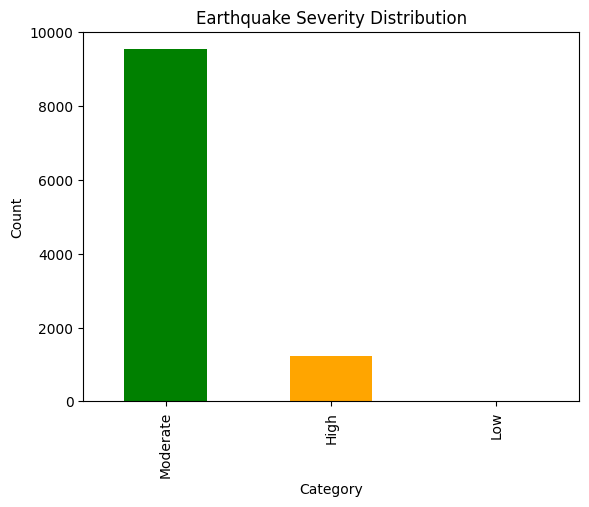

In [52]:
# ===== CATEGORY DISTRIBUTION =====

df['mag_category'].value_counts().plot(
    kind='bar',
    color=['green','orange','red']
)

plt.title("Earthquake Severity Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

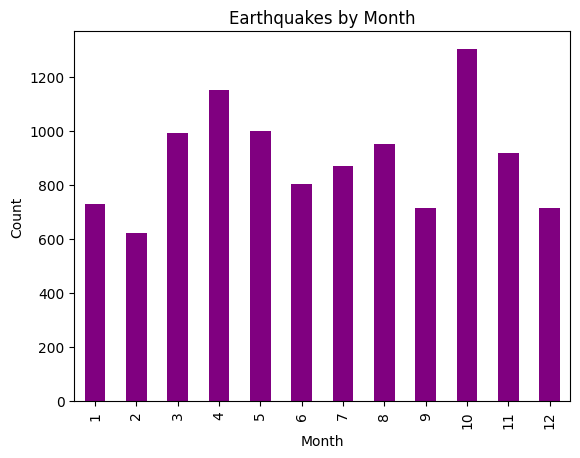

In [53]:
# ===== EARTHQUAKES PER MONTH =====

df['month'].value_counts().sort_index().plot(
    kind='bar',
    color='purple'
)

plt.title("Earthquakes by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

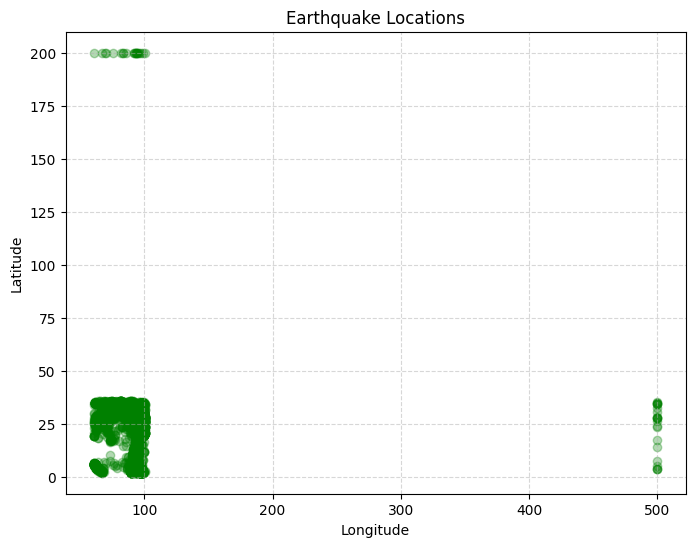

In [54]:
# ===== LOCATION PLOT =====

plt.figure(figsize=(8,6))

plt.scatter(
    df['longitude'],
    df['latitude'],
    alpha=0.3,
    color='green'
)

plt.title("Earthquake Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

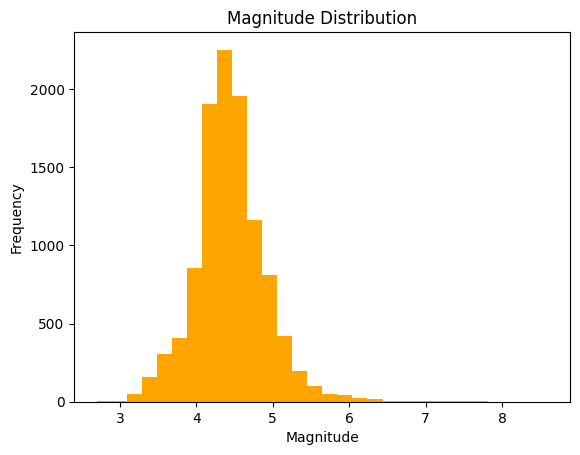

In [55]:
# ===== MAGNITUDE DISTRIBUTION =====

plt.hist(df['mag'], bins=30, color='orange')

plt.title("Magnitude Distribution")
plt.xlabel("Magnitude")
plt.ylabel("Frequency")
plt.show()

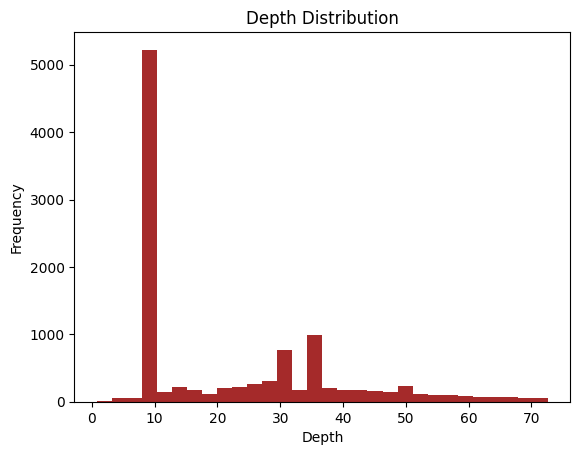

In [56]:
# ===== DEPTH DISTRIBUTION =====

plt.hist(df['depth'], bins=30, color='brown')

plt.title("Depth Distribution")
plt.xlabel("Depth")
plt.ylabel("Frequency")
plt.show()

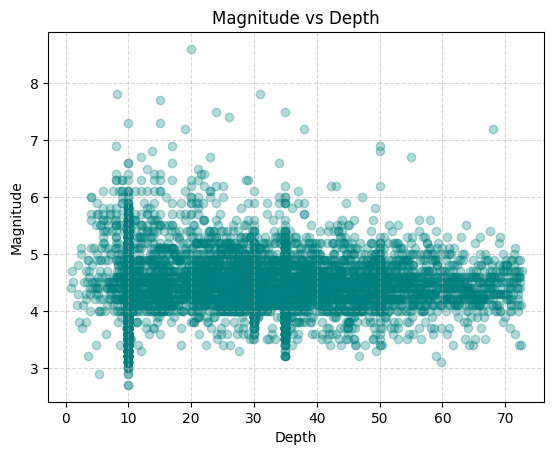

In [57]:
# ===== MAGNITUDE VS DEPTH =====

plt.scatter(
    df['depth'],
    df['mag'],
    alpha=0.3,
    color='teal'
)

plt.xlabel("Depth")
plt.ylabel("Magnitude")
plt.title("Magnitude vs Depth")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

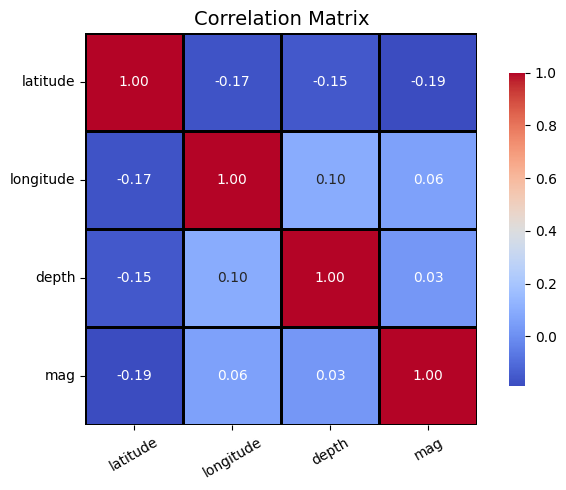

In [74]:
# ===== CORRELATION =====

import seaborn as sns
# ===== CORRELATION HEATMAP (IMPROVED) =====

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

corr = df[['latitude','longitude','depth','mag']].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',     # better contrast than 'warm'
    linewidths=1,
    linecolor='black',
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix", fontsize=14)
plt.xticks(rotation=30)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [75]:
# ===== IMPORTS =====

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [76]:
# ===== LOAD DATA =====

df = pd.read_csv("cleaned_earthquake_data.csv")

print(df.shape)
print(df.head())

(10759, 8)
                               time  latitude  longitude   depth  mag  \
0  2024-10-31 01:32:40.503000+00:00   29.8573    92.2470  10.000  4.4   
1  2024-10-30 23:51:31.217000+00:00   28.2099    67.0879  10.000  4.3   
2  2024-10-29 02:35:27.930000+00:00    4.7184    96.2377  42.117  4.6   
3  2024-10-28 13:08:40.107000+00:00   27.8734    94.0243  36.279  4.6   
4  2024-10-23 21:11:18.779000+00:00   32.7498    90.4178  10.000  4.0   

                            place  year  month  
0      113 km ENE of Lhasa, China  2024     10  
1   64 km NE of Khuzdar, Pakistan  2024     10  
2  55 km S of Reuleuet, Indonesia  2024     10  
3        35 km NNE of Ziro, India  2024     10  
4       209 km NW of Nagqu, China  2024     10  


In [77]:
# ===== FEATURES & TARGET =====

features = ['latitude', 'longitude', 'depth']
target = 'mag'

X = df[features]
y = df[target]

In [78]:
# ===== SPLIT DATA =====

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (8607, 3)
Test size: (2152, 3)


In [72]:
# ===== LINEAR REGRESSION =====

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
# ===== RANDOM FOREST =====

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
# ===== GRADIENT BOOSTING =====

gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

In [79]:
# ===== 6. EVALUATION FUNCTION =====
def evaluate(model, name):
    pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    print(f"{name} R2:", r2)
    print(f"{name} RMSE:", rmse)
    print("-"*30)

    return pred

pred_lr = evaluate(lr, "Linear")
pred_rf = evaluate(rf, "Random Forest")
pred_gb = evaluate(gb, "Gradient Boosting")

Linear R2: 0.028316452840536743
Linear RMSE: 0.4740525334202207
------------------------------
Random Forest R2: 0.08848117392567467
Random Forest RMSE: 0.4591418382585115
------------------------------
Gradient Boosting R2: 0.1575518409606418
Gradient Boosting RMSE: 0.4414033654260402
------------------------------


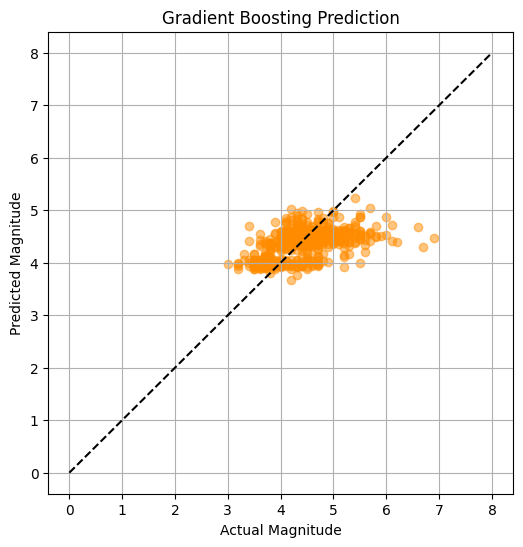

In [68]:
# ===== 7. VISUALIZATION (CLEAN GRAPH) =====

# sample to avoid clutter
idx = np.random.choice(len(y_test), size=1000, replace=False)

plt.figure(figsize=(6,6))

plt.scatter(
    y_test.iloc[idx],
    pred_gb[idx],
    color='darkorange',
    alpha=0.5
)

# ideal line
plt.plot([0,8],[0,8], color='black', linestyle='--')

plt.xlabel("Actual Magnitude")
plt.ylabel("Predicted Magnitude")
plt.title("Gradient Boosting Prediction")
plt.grid(True)

plt.show()

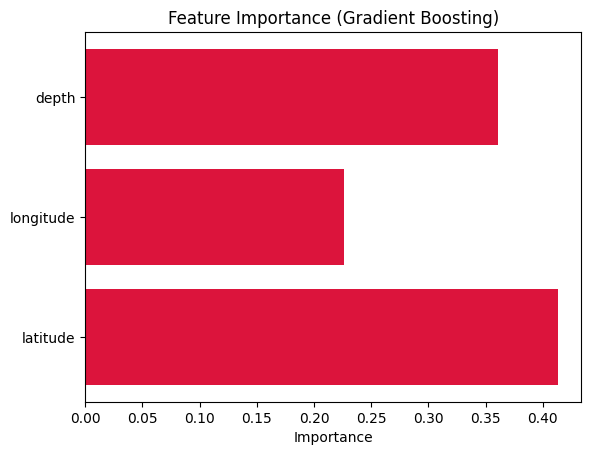

In [80]:
# ===== 8. FEATURE IMPORTANCE =====

importances = gb.feature_importances_

plt.barh(features, importances, color='crimson')

plt.title("Feature Importance (Gradient Boosting)")
plt.xlabel("Importance")

plt.show()

In [84]:
# ===== MAGNITUDE MODEL =====

import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Load dataset
df = pd.read_csv("cleaned_earthquake_data.csv")

# Features
features = ['latitude', 'longitude', 'depth', 'year', 'month']
X = df[features]
y = df['mag']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model_mag = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5
)

model_mag.fit(X_train, y_train)

# Evaluation
pred = model_mag.predict(X_test)

print("R2:", r2_score(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred)**0.5)

# Save
joblib.dump(model_mag, "earthquake_model.pkl")

R2: 0.22272227697459623
RMSE: 0.4134217791841524


['earthquake_model.pkl']

In [85]:
# ===== RISK MODEL =====

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create risk label
df['risk'] = (df['mag'] >= 5).astype(int)

X = df[['latitude','longitude','depth','year','month']]
y = df['risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model_risk = RandomForestClassifier(n_estimators=150)
model_risk.fit(X_train, y_train)

# Evaluation
pred = model_risk.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

# Save
joblib.dump(model_risk, "risk_model.pkl")

Accuracy: 0.8726765799256505


['risk_model.pkl']

In [86]:
import sklearn
import numpy
import joblib

print(sklearn.__version__)
print(numpy.__version__)
print(joblib.__version__)

1.6.1
2.0.2
1.5.3
